# Reinforcement Learning (Simple example 1)
This example utilizes no deep learning or external libraries. It uses:
- Q-learning (value-based method)
- Simple grid environment (5x5)
- The agent learns to reach the goal while avoiding obstacles

### Key concepts:
- **Agent**:	The learner navigating from (0,0)
- **Environment**:	The 5x5 grid, with GOAL and OBSTACLES
- **Action**:	Move up, down, left, right
- **Observation**:	Current position on grid (x, y)
- **Reward**:	+10 for goal, -1 step penalty, -10 for obstacle

## Style 1: no classes used here

In [10]:
import numpy as np
import random
import time

# Define Grid Environment
GRID_SIZE = 5
GOAL = (4, 4)
OBSTACLES = [(1, 1), (2, 2), (3, 1)]
ACTIONS = ['up', 'down', 'left', 'right']
ACTION_IDX = {a: i for i, a in enumerate(ACTIONS)}
print(f"ACTION_IDX: \n{ACTION_IDX}")

# Parameters
alpha = 0.1       # learning rate
gamma = 0.9       # discount factor
epsilon = 0.2     # exploration rate
episodes = 500

# Initialize Q-table: state (x, y), action
Q = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTIONS)))

def is_valid(state):
    x, y = state
    return 0 <= x < GRID_SIZE and 0 <= y < GRID_SIZE and state not in OBSTACLES

def get_next_state(state, action):
    x, y = state
    if action == 'up':
        next_state = (x - 1, y)
    elif action == 'down':
        next_state = (x + 1, y)
    elif action == 'left':
        next_state = (x, y - 1)
    else:  # 'right'
        next_state = (x, y + 1)
    return next_state if is_valid(next_state) else state

def get_reward(state):
    if state == GOAL:
        return 10
    elif state in OBSTACLES:
        return -10
    else:
        return -1  # small penalty to encourage shortest path

# Training
for ep in range(episodes):
    state = (0, 0)  # start position
    while state != GOAL:
        # ε-greedy action selection
        if random.random() < epsilon:
            action = random.choice(ACTIONS)
        else:
            action = ACTIONS[np.argmax(Q[state])]

        next_state = get_next_state(state, action)
        reward = get_reward(next_state)

        # Q-learning update
        best_next_action = np.max(Q[next_state])
        Q[state][ACTION_IDX[action]] += alpha * (reward + gamma * best_next_action - Q[state][ACTION_IDX[action]])

        state = next_state

# Test agent after training
def print_policy():
    policy_grid = []
    for i in range(GRID_SIZE):
        row = []
        for j in range(GRID_SIZE):
            if (i, j) == GOAL:
                row.append('G')
            elif (i, j) in OBSTACLES:
                row.append('X')
            else:
                best_action = np.argmax(Q[(i, j)])
                row.append(ACTIONS[best_action][0].upper())  # U, D, L, R
        policy_grid.append(row)
    for row in policy_grid:
        print(' '.join(row))

print("\nLearned Policy Grid:")
print_policy()


ACTION_IDX: 
{'up': 0, 'down': 1, 'left': 2, 'right': 3}

Learned Policy Grid:
R R R D D
U X R R D
D U X R D
D X D R D
R R R R G


This means:

From any cell, follow the direction (U/D/L/R) to reach goal

‘X’ marks obstacles

‘G’ marks the goal

## Style 2: Classes used here

In [11]:
import numpy as np
import random

# Environment class
class GridWorldEnv:
    def __init__(self, size=5, goal=(4, 4), obstacles=None):
        self.size = size
        self.goal = goal
        self.obstacles = obstacles or [(1, 1), (2, 2), (3, 1)]
        self.actions = ['up', 'down', 'left', 'right']
        self.reset()

    def reset(self):
        self.agent_pos = (0, 0)
        return self.agent_pos

    def is_valid(self, state):
        x, y = state
        return 0 <= x < self.size and 0 <= y < self.size and state not in self.obstacles

    def step(self, action):
        x, y = self.agent_pos
        if action == 'up':
            next_state = (x - 1, y)
        elif action == 'down':
            next_state = (x + 1, y)
        elif action == 'left':
            next_state = (x, y - 1)
        elif action == 'right':
            next_state = (x, y + 1)
        else:
            raise ValueError("Invalid Action")

        if self.is_valid(next_state):
            self.agent_pos = next_state
        else:
            next_state = self.agent_pos  # stay in place

        reward = self.get_reward(next_state)
        done = (next_state == self.goal)
        return next_state, reward, done

    def get_reward(self, state):
        if state == self.goal:
            return 10
        elif state in self.obstacles:
            return -10
        else:
            return -1  # penalty for each step

# Agent class
class Agent:
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.env = env
        self.alpha = alpha      # learning rate
        self.gamma = gamma      # discount factor
        self.epsilon = epsilon  # exploration rate
        self.q_table = np.zeros((env.size, env.size, len(env.actions)))
        self.action_map = {i: a for i, a in enumerate(env.actions)}
        self.action_idx = {a: i for i, a in enumerate(env.actions)}

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.env.actions)
        else:
            x, y = state
            best_idx = np.argmax(self.q_table[x, y])
            return self.action_map[best_idx]

    def learn(self, state, action, reward, next_state):
        x, y = state
        nx, ny = next_state
        a_idx = self.action_idx[action]
        future_reward = np.max(self.q_table[nx, ny])
        self.q_table[x, y, a_idx] += self.alpha * (reward + self.gamma * future_reward - self.q_table[x, y, a_idx])

    def train(self, episodes=500):
        for ep in range(episodes):
            state = self.env.reset()
            done = False
            while not done:
                action = self.choose_action(state)
                next_state, reward, done = self.env.step(action)
                self.learn(state, action, reward, next_state)
                state = next_state

    def get_policy_grid(self):
        grid = []
        for i in range(self.env.size):
            row = []
            for j in range(self.env.size):
                if (i, j) == self.env.goal:
                    row.append("G")
                elif (i, j) in self.env.obstacles:
                    row.append("X")
                else:
                    best_action = np.argmax(self.q_table[i, j])
                    row.append(self.env.actions[best_action][0].upper())  # U/D/L/R
            grid.append(row)
        return grid

# Run everything
env = GridWorldEnv()
agent = Agent(env)
agent.train(episodes=500)

# Show learned policy
policy = agent.get_policy_grid()
print("\nLearned Policy Grid:")
for row in policy:
    print(" ".join(row))



Learned Policy Grid:
R R R D D
U X R R D
D R X R D
D X D R D
R R R R G


## Lets add some visualization
The plot will show:
- Grid of the environment
- Black blocks = obstacles
- Green block = goal
- Blue path = the agent’s path to the goal
- Numbers = step sequence

Teaching Suggestions:
- Ask students to change obstacles and observe new paths.
- Let them reduce training episodes and see how learning worsens.
- Discuss how the Q-table evolves and why the path is (or isn’t) optimal.

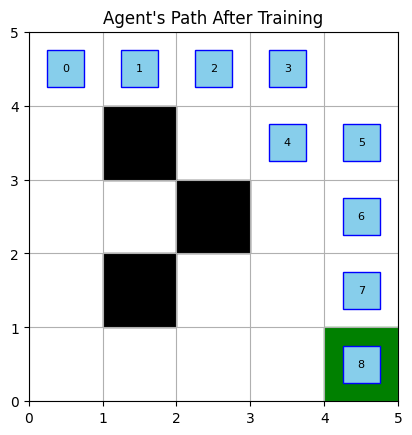

In [12]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----------- Environment Class -------------
class GridWorldEnv:
    def __init__(self, size=5, goal=(4, 4), obstacles=None):
        self.size = size
        self.goal = goal
        self.obstacles = obstacles or [(1, 1), (2, 2), (3, 1)]
        self.actions = ['up', 'down', 'left', 'right']
        self.reset()

    def reset(self):
        self.agent_pos = (0, 0)
        return self.agent_pos

    def is_valid(self, state):
        x, y = state
        return 0 <= x < self.size and 0 <= y < self.size and state not in self.obstacles

    def step(self, action):
        x, y = self.agent_pos
        if action == 'up':
            next_state = (x - 1, y)
        elif action == 'down':
            next_state = (x + 1, y)
        elif action == 'left':
            next_state = (x, y - 1)
        elif action == 'right':
            next_state = (x, y + 1)
        else:
            raise ValueError("Invalid Action")

        if self.is_valid(next_state):
            self.agent_pos = next_state
        else:
            next_state = self.agent_pos  # stay in place

        reward = self.get_reward(next_state)
        done = (next_state == self.goal)
        return next_state, reward, done

    def get_reward(self, state):
        if state == self.goal:
            return 10
        elif state in self.obstacles:
            return -10
        else:
            return -1

# ----------- Agent Class -------------
class Agent:
    def __init__(self, env, alpha=0.1, gamma=0.9, epsilon=0.2):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((env.size, env.size, len(env.actions)))
        self.action_map = {i: a for i, a in enumerate(env.actions)}
        self.action_idx = {a: i for i, a in enumerate(env.actions)}

    def choose_action(self, state):
        if random.random() < self.epsilon:
            return random.choice(self.env.actions)
        else:
            x, y = state
            best_idx = np.argmax(self.q_table[x, y])
            return self.action_map[best_idx]

    def learn(self, state, action, reward, next_state):
        x, y = state
        nx, ny = next_state
        a_idx = self.action_idx[action]
        future_reward = np.max(self.q_table[nx, ny])
        self.q_table[x, y, a_idx] += self.alpha * (reward + self.gamma * future_reward - self.q_table[x, y, a_idx])

    def train(self, episodes=500):
        for _ in range(episodes):
            state = self.env.reset()
            done = False
            while not done:
                action = self.choose_action(state)
                next_state, reward, done = self.env.step(action)
                self.learn(state, action, reward, next_state)
                state = next_state

    def get_path(self): # substituted get_policy_grid with this
        path = []
        state = self.env.reset()
        path.append(state)
        visited = set()
        for _ in range(50):  # limit to prevent infinite loop
            x, y = state
            action = self.action_map[np.argmax(self.q_table[x, y])]
            next_state, _, done = self.env.step(action)
            path.append(next_state)
            if done or next_state in visited:
                break
            visited.add(next_state)
            state = next_state
        return path

# ----------- Visualization -------------
def visualize_path(env, path):
    fig, ax = plt.subplots()
    ax.set_xlim(0, env.size)
    ax.set_ylim(0, env.size)
    ax.set_xticks(np.arange(0, env.size + 1, 1))
    ax.set_yticks(np.arange(0, env.size + 1, 1))
    ax.grid(True)

    # Draw Obstacles
    for (x, y) in env.obstacles:
        rect = patches.Rectangle((y, env.size - 1 - x), 1, 1, linewidth=1, edgecolor='black', facecolor='black')
        ax.add_patch(rect)

    # Draw Goal
    gx, gy = env.goal
    rect = patches.Rectangle((gy, env.size - 1 - gx), 1, 1, linewidth=1, edgecolor='green', facecolor='green')
    ax.add_patch(rect)

    # Draw Agent Path
    for i, (x, y) in enumerate(path):
        rect = patches.Rectangle((y + 0.25, env.size - 1 - x + 0.25), 0.5, 0.5,
                                 linewidth=1, edgecolor='blue', facecolor='skyblue')
        ax.add_patch(rect)
        ax.text(y + 0.5, env.size - 1 - x + 0.5, str(i), color='black', fontsize=8, ha='center', va='center')

    plt.title("Agent's Path After Training")
    plt.gca().set_aspect('equal')
    plt.show()

# ----------- Run It All -------------
env = GridWorldEnv()
agent = Agent(env)
agent.train(episodes=1000)

# Show path after learning
path = agent.get_path()
visualize_path(env, path)


### lets get animated .gif file for better visualization

Saved animation as agent_path.gif


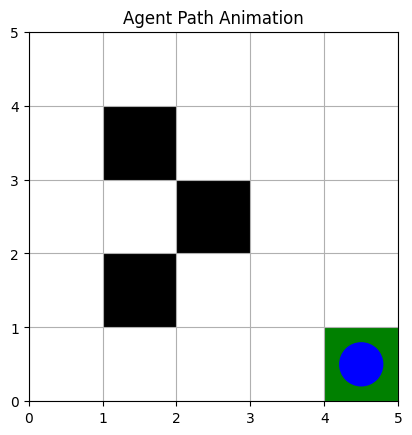

In [14]:
import matplotlib.patches as patches
from matplotlib import animation

# ----------- Animation -------------
def animate_path(env, path):
    fig, ax = plt.subplots()
    ax.set_xlim(0, env.size)
    ax.set_ylim(0, env.size)
    ax.set_xticks(np.arange(0, env.size + 1, 1))
    ax.set_yticks(np.arange(0, env.size + 1, 1))
    ax.grid(True)
    ax.set_title("Agent Path Animation")

    # Draw obstacles
    for (x, y) in env.obstacles:
        rect = patches.Rectangle((y, env.size - 1 - x), 1, 1, facecolor='black')
        ax.add_patch(rect)

    # Draw goal
    gx, gy = env.goal
    goal_rect = patches.Rectangle((gy, env.size - 1 - gx), 1, 1, facecolor='green')
    ax.add_patch(goal_rect)

    # Agent marker
    agent_patch = patches.Circle((0.5, env.size - 1 - 0.5), 0.3, facecolor='blue')
    ax.add_patch(agent_patch)

    def update(frame):
        x, y = path[frame]
        agent_patch.center = (y + 0.5, env.size - 1 - x + 0.5)
        return agent_patch,

    anim = animation.FuncAnimation(fig, update, frames=len(path), interval=500, blit=True, repeat=False)
    plt.gca().set_aspect('equal')
    # plt.show()
    from matplotlib.animation import PillowWriter
    anim.save("agent_path.gif", writer=PillowWriter(fps=2))
    print("Saved animation as agent_path.gif")

# ----------- Run All -------------
env = GridWorldEnv()
agent = Agent(env)
agent.train(episodes=1000)

path = agent.get_path()
animate_path(env, path)